## Image texture classification project

# Descriable Textures Dataset
This is a collection of textural based iamges annotated with attributes inspired by percepted properties of these textures. The aim here will be to train a classiifier on these collection of images and judge the performance on unseen/test data

Import libraries


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2 # Efficient pre-trained model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.9.2


# Load and Prepare Data

We will specify the path to the dataset directory. We'll use the 'image_dataset_from_directory' to load the images and infer class labels as the directory is structured. We will also split the data into training and validation sets.

In [7]:
# Config
dataset_dir = 'dtd\images'
image_height = 224
image_width = 224
batch_size = 32


In [8]:
# Load dataset
print("Loading training data...")
train_ds = image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(image_height, image_width),
  batch_size=batch_size)


Loading training data...
Found 5640 files belonging to 47 classes.
Using 4512 files for training.


In [9]:
print("Loading validation data...")
val_ds = image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(image_height, image_width),
  batch_size=batch_size)


Loading validation data...
Found 5640 files belonging to 47 classes.
Using 1128 files for validation.


In [10]:
# --- Get Class Names ---
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nFound {num_classes} classes: {class_names}")


Found 47 classes: ['banded', 'blotchy', 'braided', 'bubbly', 'bumpy', 'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline', 'dotted', 'fibrous', 'flecked', 'freckled', 'frilly', 'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced', 'knitted', 'lacelike', 'lined', 'marbled', 'matted', 'meshed', 'paisley', 'perforated', 'pitted', 'pleated', 'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared', 'spiralled', 'sprinkled', 'stained', 'stratified', 'striped', 'studded', 'swirly', 'veined', 'waffled', 'woven', 'wrinkled', 'zigzagged']


In [11]:
# --- Configure for Performance ---
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

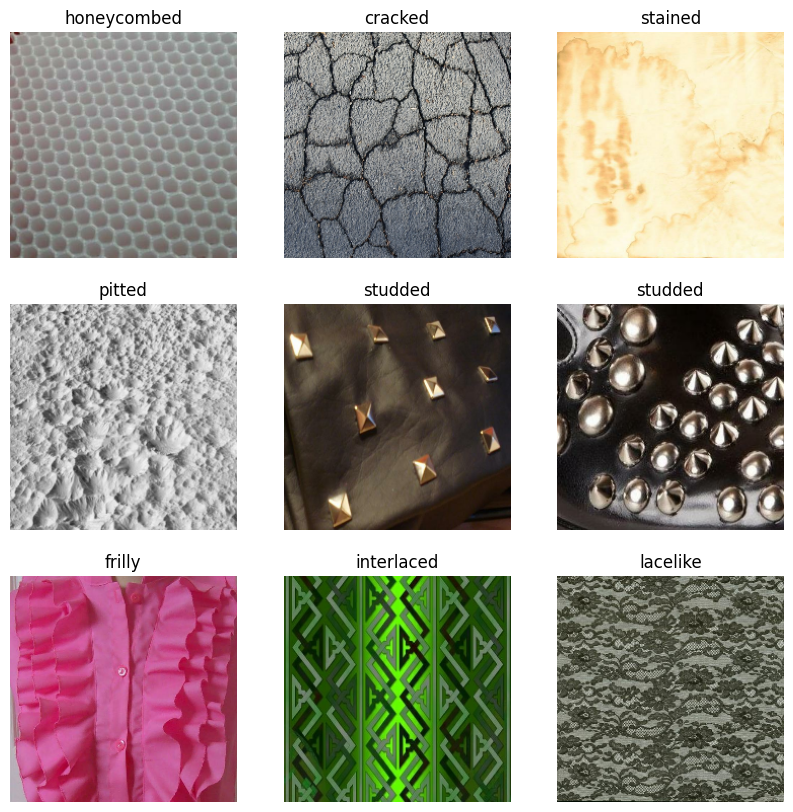

In [12]:
# --- Verify Data ---
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

# Model Architecture
We will build a simple CNN model. It starts with a `Rescaling` layer to normalise the pixel values from the [0, 255] to [0, 1]. Proceding that, several `Conv2D` (convultion) and `MaxPooling2D` (pooling) layers are used to extract features, followed by a `Flatten` layer and `Dense` (fully connected) layers for classification.

In [57]:
base_model = MobileNetV2(input_shape=(image_height, image_width, 3), include_top=False, weights='imagenet')
# After defining the base_model
base_model.trainable = False

# Unfreeze the top layers (just a few blocks)
# Find the layer index to unfreeze from
fine_tune_at = 120  # Unfreeze approximately the last 30 layers (out of 150+ in MobileNetV2)

# Unfreeze the top layers of the model
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),  # Increased from 0.1
        layers.RandomZoom(0.2),      # Increased from 0.1
        layers.RandomContrast(0.2),  # New - textures differ in contrast
        layers.RandomBrightness(0.2), # New - helps with lighting invariance
    ]
)

# Start with the input layer
inputs = Input(shape=(image_height, image_width, 3))
# Apply augmentation (only during training)
x = data_augmentation(inputs)
# Preprocess input for MobileNetV2 (scales pixels to [-1, 1])
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
# Pass data through the frozen base model
x = base_model(x, training=False) # Set training=False for the frozen base
# Pool the features
x = GlobalAveragePooling2D()(x)
# Add dropout for regularization
x = Dropout(0.4)(x) # Can start with a lower dropout rate for transfer learning
# Add the final classification layer
outputs = Dense(num_classes, activation='softmax')(x)

# Combine into the final model
model = Model(inputs, outputs)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 47)             │        60,207 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,318,191 (8.84 MB)

 Trainable params: 1,685,103 (6.43 MB)

 Non-trainable params: 633,088 (2.42 MB)

# Copmpile the model

Before training, we need to configure the learning process. We'll specify the optimizer, the loss function, and the metrics to monitor.
- **Optimizer:** We'll use Adam, a popular gradient descent optimization algorithm.
- **Loss Function:** Since we have multiple classes and the labels are integers (provided by `image_dataset_from_directory`), we'll use `SparseCategoricalCrossentropy`.
- **Metrics:** We'll monitor `accuracy` to see how well the model classifies the images.

In [58]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Lower LR often better
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train the Model

Now we train the model using the `fit` method. We pass it the training data (`train_ds`), the validation data (`val_ds`), and specify the number of `epochs` (iterations over the entire dataset) to train for. We'll store the training history to visualize the performance later.

In [59]:
epochs = 10 


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10, 
    restore_best_weights=True
)

# Learning Rate Scheduler 
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', # Monitor validation loss
    factor=0.2,         # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=3,         # Number of epochs with no improvement after which learning rate will be reduced.
    min_lr=0.00001      # Lower bound on the learning rate.
)


print("Starting training...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stopping, reduce_lr], # Add reduce_lr callback here
)
print("Training finished.")

actual_epochs = len(history.history['loss'])
print(f"Actual number of epochs: {actual_epochs}")

Starting training...
Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step - accuracy: 0.2736 - loss: 2.9581 - val_accuracy: 0.1472 - val_loss: 6.3706 - learning_rate: 5.0000e-04
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 231ms/step - accuracy: 0.5822 - loss: 1.4410 - val_accuracy: 0.2713 - val_loss: 5.3627 - learning_rate: 5.0000e-04
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 228ms/step - accuracy: 0.6828 - loss: 1.0625 - val_accuracy: 0.3129 - val_loss: 4.2132 - learning_rate: 5.0000e-04
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.7191 - loss: 0.8970 - val_accuracy: 0.2119 - val_loss: 6.7374 - learning_rate: 5.0000e-04
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.7868 - loss: 0.6733 - val_accuracy: 0.1995 - val_loss: 7.4072 - learning_rate: 5.0000e-04
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.7977 - loss: 0.6254 - val_accuracy: 0.2181 - val_loss: 7.1513 - learning_rate: 5.0000e-04
Epoch 7/10
141/141 ━━━━━━

In [66]:
print("Fine-tuning the model...")
# Unfreeze the top layers of the model
fine_tune_at = 120
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Re-compile with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower learning rate for fine-tuning
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Train for additional epochs
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # Just a few additional epochs
    callbacks=[early_stopping, reduce_lr]
)

Fine-tuning the model...
Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 245ms/step - accuracy: 0.9717 - loss: 0.0956 - val_accuracy: 0.6294 - val_loss: 1.9666 - learning_rate: 1.0000e-04
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.9801 - loss: 0.0739 - val_accuracy: 0.6348 - val_loss: 1.8999 - learning_rate: 1.0000e-04
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 233ms/step - accuracy: 0.9800 - loss: 0.0750 - val_accuracy: 0.6489 - val_loss: 1.8920 - learning_rate: 1.0000e-04
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 234ms/step - accuracy: 0.9844 - loss: 0.0631 - val_accuracy: 0.6543 - val_loss: 1.9331 - learning_rate: 1.0000e-04
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 238ms/step - accuracy: 0.9880 - loss: 0.0467 - val_accuracy: 0.6454 - val_loss: 1.8886 - learning_rate: 1.0000e-04
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 234ms/step - accuracy: 0.9882 - loss: 0.0461 - val_accuracy: 0.6489 - val_loss: 1.8989 - learning_rate: 1.0000e-04
Epoch 7/10
141/141 ━━

# Save the Model

We can save the, now, trained model so it can be loaded later without retraining

In [67]:
model_save_path = 'texture_classifier_model.keras'
print(f"Saving model to {model_save_path}...")
model.save(model_save_path)
print("Model saved.")

Saving model to texture_classifier_model.keras...
Model saved.


# Evaluate Model Performance

Let's see how the model performs on the validation set. We'll also visualize the training and validation accuracy and loss over the epochs to understand the learning process and check for signs of overfitting.


Evaluating model on validation data...
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.6679 - loss: 1.8776
Validation Loss: 1.8730
Validation Accuracy: 0.6560


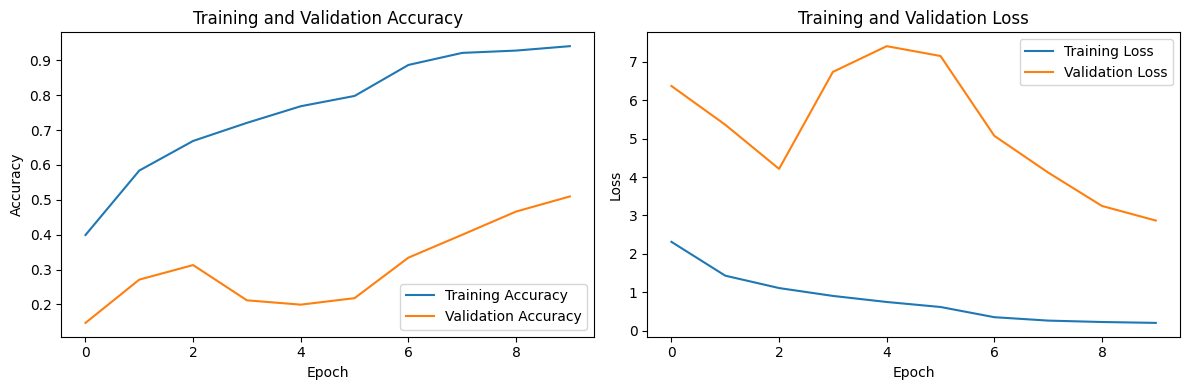

In [68]:
# --- Evaluate on Validation Set ---
print("\nEvaluating model on validation data...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# --- Visualize Training History ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(actual_epochs)  # Use actual_epochs to match the length of acc, val_acc, loss, and val_loss

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

# Image prediction  

Load the saved model and use it to predict the classes for a batch of images from the validation set (acting as unseen data).


Making predictions on a batch of validation images...


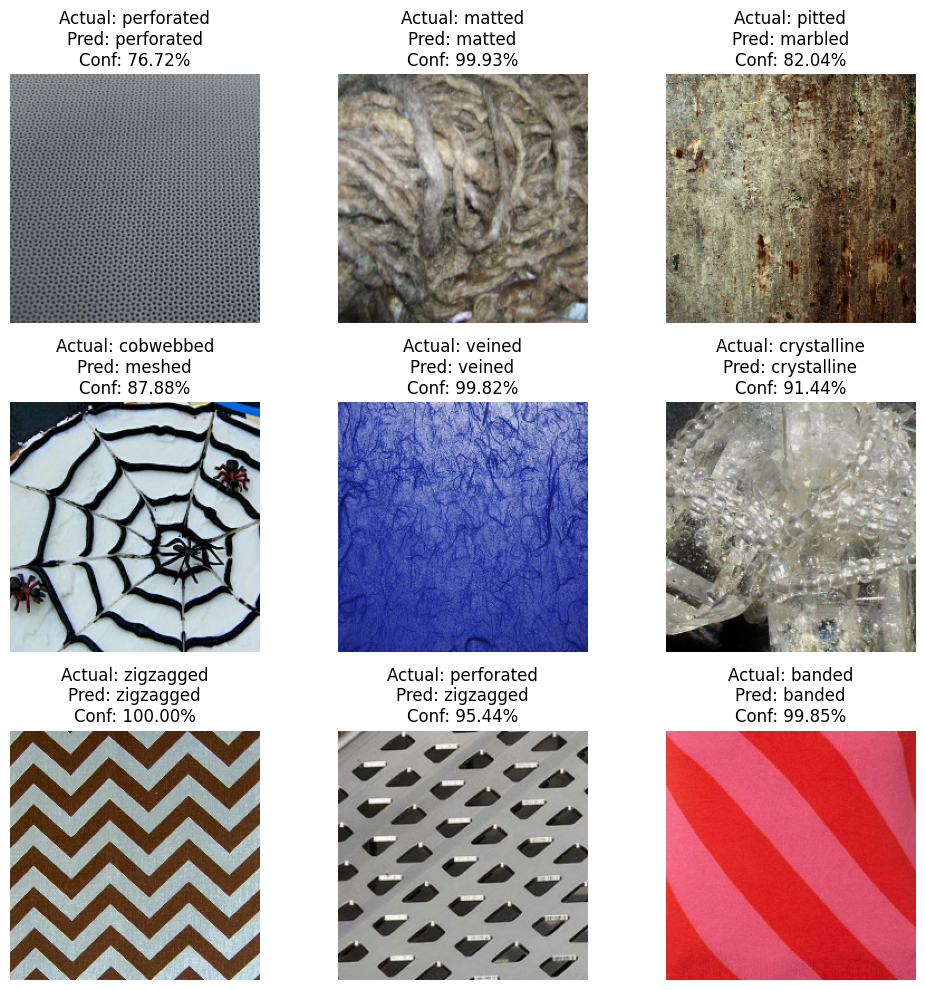


Evaluating loaded model on validation data...
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.6679 - loss: 1.8776
Loaded Model Validation Loss: 1.8730
Loaded Model Validation Accuracy: 0.6560


In [70]:
# --- Get a Batch of Unseen Images ---
# Take one batch from the validation dataset
val_iterator = iter(val_ds)
image_batch, label_batch = next(val_iterator)

# --- Make Predictions ---
print("\nMaking predictions on a batch of validation images...")
predictions = model(image_batch)

# --- Display Predictions ---
plt.figure(figsize=(10, 10))
for i in range(9): # Display first 9 images from the batch
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    predicted_class_index = np.argmax(predictions[i])
    predicted_class_name = class_names[predicted_class_index]
    actual_class_name = class_names[label_batch[i]]
    confidence = 100 * np.max(predictions[i])

    plt.title(f"Actual: {actual_class_name}\nPred: {predicted_class_name}\nConf: {confidence:.2f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Optional: Evaluate the loaded model again to confirm it's the same
print("\nEvaluating loaded model on validation data...")
loss, accuracy = model.evaluate(val_ds)
print(f"Loaded Model Validation Loss: {loss:.4f}")
print(f"Loaded Model Validation Accuracy: {accuracy:.4f}")